In [3]:
import roadrunner
import numpy as np 
import matplotlib.pyplot as plt 

# Load the model
rr = roadrunner.RoadRunner('LipniackiWithCYLD.xml')

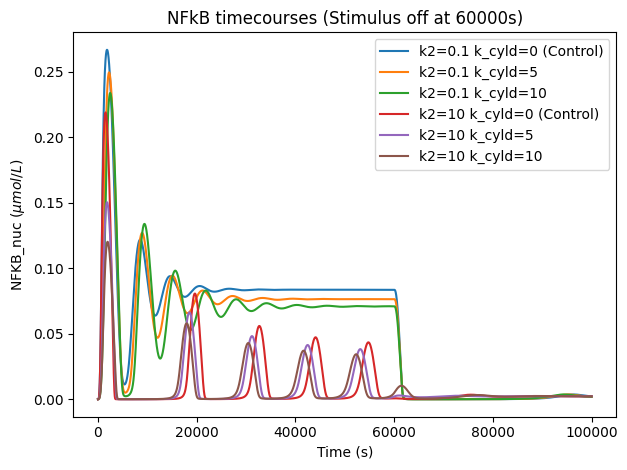

In [4]:
def set_stimulus(on_value = 1.0):
    if "TNF_R" not in rr.model.getGlobalParameterIds():
        raise RuntimeError("TNF_R not found as a global parameter")
    rr["TNF_R"] = float(on_value)

def run_timecourse_tnf_pulse(rr, params, t_off, t_end, n, vars_out):
    rr.resetAll()

    # Set parameters
    for k, v in params.items():
        if isinstance(v, (int, float, np.integer, np.floating)):
            rr[k] = float(v)

    # Time grid
    tgrid = np.linspace(0.0, float(t_end), int(n))
    ioff = int(np.searchsorted(tgrid, float(t_off)))

    # Clamp so we always have at least 2 points in each segment
    ioff = max(1, min(ioff, len(tgrid) - 2))

    # TNF on
    set_stimulus(1.0)
    rr.timeCourseSelections = list(vars_out)
    sim_on = rr.simulate(0.0, float(tgrid[ioff]), int(ioff) + 1)

    # TNF off
    set_stimulus(0.0)
    sim_off = rr.simulate(float(tgrid[ioff]), float(t_end), int(len(tgrid) - ioff))

    # Stich
    sim = np.vstack((sim_on, sim_off[1:]))
    return sim

regimes = [
    {"label":"k2=0.1 k_cyld=0 (Control)", "k_cyld":0.0, "k2":0.1},
    {"label":"k2=0.1 k_cyld=5", "k_cyld":5.0, "k2":0.1},
    {"label":"k2=0.1 k_cyld=10", "k_cyld":10.0, "k2":0.1},
    {"label":"k2=10 k_cyld=0 (Control)", "k_cyld":0.0, "k2":10.0},
    {"label":"k2=10 k_cyld=5", "k_cyld":5.0, "k2":10.0},
    {"label":"k2=10 k_cyld=10", "k_cyld":10.0, "k2":10.0},
    
]

plt.figure()
for r in regimes:
    m = run_timecourse_tnf_pulse(rr, r, t_off=60000, t_end=100000, n=5001, vars_out=["time", "NFKB_nuc"])
    plt.plot(m[:,0], m[:,1], label=r["label"])

plt.title("NFkB timecourses (Stimulus off at 60000s)")
plt.xlabel("Time (s)")
plt.ylabel(r"NFKB_nuc ($\mu mol/L$)")
plt.legend()
plt.tight_layout()
plt.show()

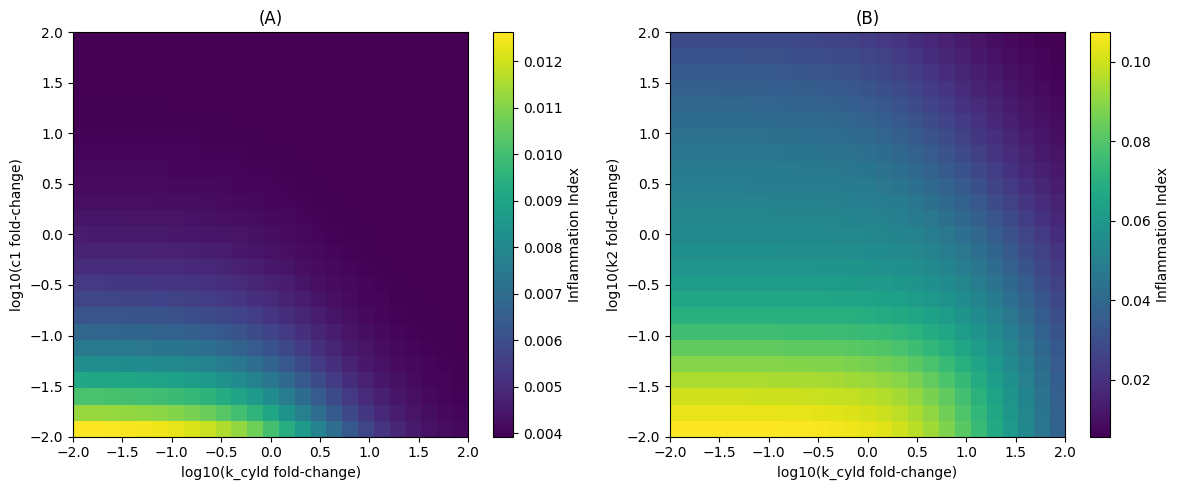

In [5]:
# Figure 3A & 3B: Inflammation Index
# 3A: (c1, k_cyld)   3B: (k2, k_cyld)

# Simulation & metric settings
simulation_end_time_seconds = 6500
num_timepoints = 4001
tnf_pulse_off_time_seconds = 3600
plateau_tail_fraction = 0.10
nfkb_output_species_id = "NFKB_nuc"

# Parameter scan settings
fold_change_min, fold_change_max, num_grid_points = 1e-2, 1e2, 25
a20_transcription_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #c1
a20_feedback_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #k2
cyld_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #k_cyld

def simulation_nfkb_under_tnf_pulse(road_runner, parameter_updates):
    """
    Piecewise simulation enforcing a TNF_R pulse:
        TNF_R = 1 from t=0 to t=tnf_pulse_off_time_seconds
        TNF_R = 0 from t=tnf_pulse_off_time_seconds to t=simulation_end_time_seconds
    parameter_updates: dict, e.g. {"c1": 0.1, "k_cyld": 10}
    Returns time, nfkb arrays
    """
    road_runner.resetAll()
    for name, value in parameter_updates.items():
        road_runner[name] = float(value)

    time_grid = np.linspace(0.0, float(simulation_end_time_seconds), int(num_timepoints))
    off_index = int(np.searchsorted(time_grid, float(tnf_pulse_off_time_seconds)))

    road_runner["TNF_R"] = 1.0
    segment_on = road_runner.simulate(0.0, float(time_grid[off_index]), off_index + 1, ["time", nfkb_output_species_id])

    road_runner["TNF_R"] = 0.0
    segment_off = road_runner.simulate(float(time_grid[off_index]), float(simulation_end_time_seconds), num_timepoints - off_index, ["time", nfkb_output_species_id])

    time = np.concatenate((segment_on[:,0], segment_off[1:,0]))
    nfkb = np.concatenate((segment_on[:,1], segment_off[1:,1]))
    return time, nfkb

def compute_inflammation_index(time, nfkb, weight_mean_exposure=0.70, weight_late_exposure=0.30):
    """
    Visual meaning: AUC = Area Under Curve
        mean exposure = (AUC above baseline) / duration
        late exposure = (plateau - baseline) using last tail_fraction of the trace
        inflammation index = weighted mean exposure _ weighted late exposure
    Returns: auc_above_baseline, plateau_above_baseline, inflammation_index
    """

    time = np.asarray(time, float)
    nfkb = np.asarray(nfkb, float)

    baseline_level = float(nfkb[0])
    nfkb_above_baseline = np.maximum(nfkb - baseline_level, 0.0)

    auc_above_baseline = float(np.trapezoid(nfkb_above_baseline, time))
    duration_seconds = float(time[-1] - time[0])
    mean_exposure = auc_above_baseline / duration_seconds if duration_seconds > 0 else 0.0

    tail_start_index = int((1.0 - float(plateau_tail_fraction)) * len(nfkb))
    plateau_level = float(np.mean(nfkb[tail_start_index:]))
    plateau_above_baseline = max(plateau_level - baseline_level, 0.0)

    inflammation_index = (weight_mean_exposure * mean_exposure) + (weight_late_exposure * plateau_above_baseline)
    return auc_above_baseline, plateau_above_baseline, inflammation_index

def compute_index_heatmap(road_runner, cyld_parameter_name, cyld_fold_grid, y_parameter_name, y_fold_grid):
    """
    Creates an inflammation-index heatmap where:
        x-axis = log10(k_cyld fold-change)
        y-axis = log10(y_parameter fold-change) [either c1 or k2]
    We hold the "other A20 parameter" at its baseline unless it is the y_parameter
    """
    index_grid = np.zeros((len(y_fold_grid), len(cyld_fold_grid)))
    for yi, y_fold in enumerate(y_fold_grid):
        for xi, cyld_fold in enumerate(cyld_fold_grid):
            parameter_updates = {
                y_parameter_name: y_fold,

                cyld_parameter_name: cyld_fold,
            }
            time, nfkb = simulation_nfkb_under_tnf_pulse(road_runner, parameter_updates)
            _, _, inflammation_index = compute_inflammation_index(time, nfkb)
            index_grid[yi, xi] = inflammation_index
    return index_grid

# Compute both panels
index_grid_c1 = compute_index_heatmap(rr, "k_cyld", cyld_fold_grid, "c1", a20_transcription_fold_grid)
index_grid_k2 = compute_index_heatmap(rr, "k_cyld", cyld_fold_grid, "k2", a20_feedback_fold_grid)

# Log based data for side-by-side comparison
x_log10_cyld = np.log10(cyld_fold_grid)
y_log10_c1 = np.log10(a20_transcription_fold_grid)
y_log10_k2 = np.log10(a20_feedback_fold_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

imageA = axes[0].imshow(index_grid_c1, origin="lower", aspect="auto", extent=[x_log10_cyld.min(), x_log10_cyld.max(), y_log10_c1.min(), y_log10_c1.max()])
axes[0].set_title("(A)")
axes[0].set_xlabel("log10(k_cyld fold-change)")
axes[0].set_ylabel("log10(c1 fold-change)")
colorbarA = plt.colorbar(imageA, ax=axes[0])
colorbarA.set_label("Inflammation Index")

imageB = axes[1].imshow(index_grid_k2, origin="lower", aspect="auto", extent=[x_log10_cyld.min(), x_log10_cyld.max(), y_log10_k2.min(), y_log10_k2.max()])
axes[1].set_title("(B)")
axes[1].set_xlabel("log10(k_cyld fold-change)")
axes[1].set_ylabel("log10(k2 fold-change)")
colorbarB = plt.colorbar(imageB, ax=axes[1])
colorbarB.set_label("Inflammation Index")

plt.tight_layout()
plt.show()


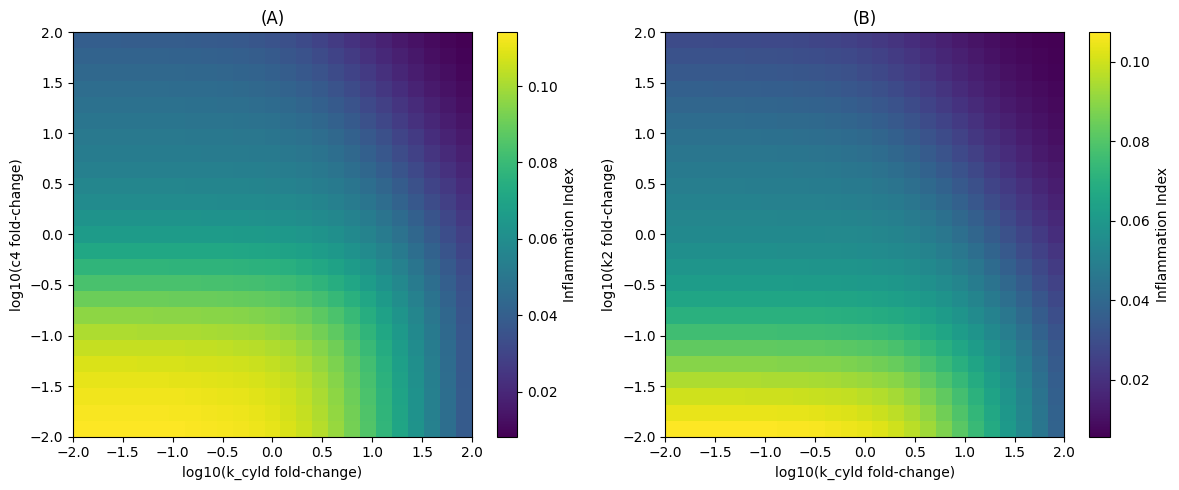

In [6]:
# Figure 4A & 4B: Inflammation Index wrt c4 and k2 against k_cyld
# 4A = (c4 k_cyld)   4B = (k2 k_cyld)

a20_transcription_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #c4
a20_feedback_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #k2
cyld_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #k_cyld

# Compute both panels
index_grid_c4 = compute_index_heatmap(rr, "k_cyld", cyld_fold_grid, "c4", a20_transcription_fold_grid)
index_grid_k2 = compute_index_heatmap(rr, "k_cyld", cyld_fold_grid, "k2", a20_feedback_fold_grid)

# Plot side-by-side as Fig 5A and 5B
x_log10_cyld = np.log10(cyld_fold_grid)
y_log10_c4 = np.log10(a20_transcription_fold_grid)
y_log10_k2 = np.log10(a20_feedback_fold_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

imageA = axes[0].imshow(index_grid_c4, origin="lower", aspect="auto", extent=[x_log10_cyld.min(), x_log10_cyld.max(), y_log10_c4.min(), y_log10_c4.max()])
axes[0].set_title("(A)")
axes[0].set_xlabel("log10(k_cyld fold-change)")
axes[0].set_ylabel("log10(c4 fold-change)")
colorbarA = plt.colorbar(imageA, ax=axes[0])
colorbarA.set_label("Inflammation Index")

imageB = axes[1].imshow(index_grid_k2, origin="lower", aspect="auto", extent=[x_log10_cyld.min(), x_log10_cyld.max(), y_log10_k2.min(), y_log10_k2.max()])
axes[1].set_title("(B)")
axes[1].set_xlabel("log10(k_cyld fold-change)")
axes[1].set_ylabel("log10(k2 fold-change)")
colorbarB = plt.colorbar(imageB, ax=axes[1])
colorbarB.set_label("Inflammation Index")

plt.tight_layout()
plt.show()

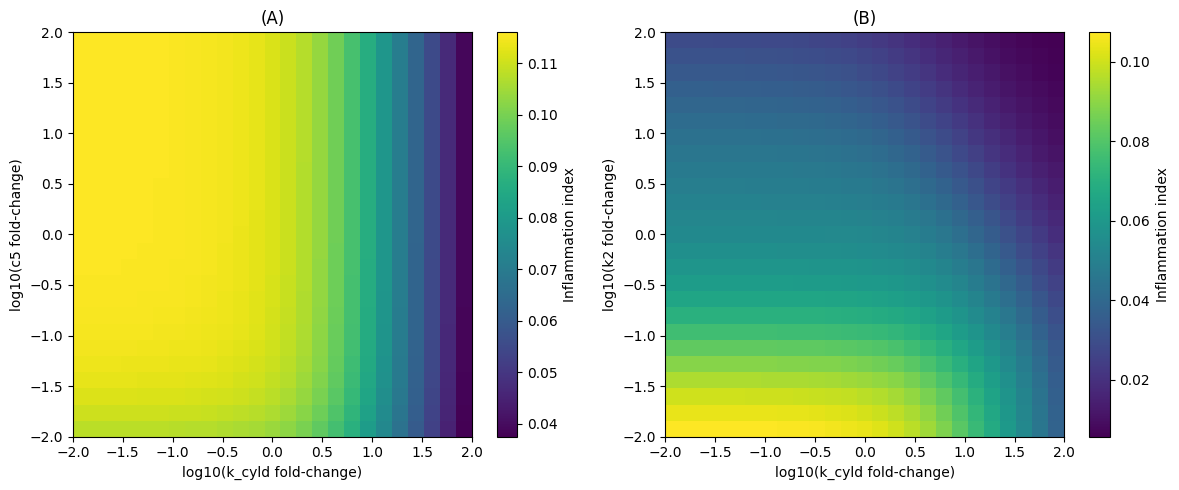

In [7]:
# Figure 5: Inflammation Index
# 5A: (c5, k_cyld)   5B: (k2, k_cyld)

a20_degradation_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #c5
a20_feedback_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #k2
cyld_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) #k_cyld

# Compute both panels
index_grid_c5 = compute_index_heatmap(rr, "k_cyld", cyld_fold_grid, "c5", a20_degradation_fold_grid)
index_grid_k2 = compute_index_heatmap(rr, "k_cyld", cyld_fold_grid, "k2", a20_feedback_fold_grid)

# Plot side-by-side as Fig 5A and 5B
x_log10_cyld = np.log10(cyld_fold_grid)
y_log10_c5 = np.log10(a20_degradation_fold_grid)
y_log10_k2 = np.log10(a20_feedback_fold_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
imageA = axes[0].imshow(index_grid_c5, origin="lower", aspect="auto", extent=[x_log10_cyld.min(), x_log10_cyld.max(), y_log10_c5.min(), y_log10_c5.max()])
axes[0].set_title("(A)")
axes[0].set_xlabel("log10(k_cyld fold-change)")
axes[0].set_ylabel("log10(c5 fold-change)")
colorbarA = plt.colorbar(imageA, ax=axes[0])
colorbarA.set_label("Inflammation index")

imageB = axes[1].imshow(index_grid_k2, origin="lower", aspect="auto", extent=[x_log10_cyld.min(), x_log10_cyld.max(), y_log10_k2.min(), y_log10_k2.max()])
axes[1].set_title("(B)")
axes[1].set_xlabel("log10(k_cyld fold-change)")
axes[1].set_ylabel("log10(k2 fold-change)")
colorbarB = plt.colorbar(imageB, ax=axes[1])
colorbarB.set_label("Inflammation index")

plt.tight_layout()
plt.show()